/tmp/ipykernel_1828344/2655529562.py:307: UserWarning: No config.yaml found for fit cosmo-base_QSO1-S2-7b3c7d8a; scale cuts are unknown.
  fit_metadata = [load_fit_metadata(config['base_dir']) for config in enabled_configs]
/tmp/ipykernel_1828344/2655529562.py:307: UserWarning: No config.yaml found for fit cosmo-base_QSO1-S2-c80b3032; scale cuts are unknown.
  fit_metadata = [load_fit_metadata(config['base_dir']) for config in enabled_configs]


,label,hash,config_status,cosmology_model,template,engine,sampler,nchains,resume,rng,nparallel,batch_size,min_steps,gelman_rubin,ess,thinning,profiler,profile_iterations
0,Lightcone v1.9 P with FolpsEFT 0.8 < z < 2.1,7b3c7d8a,config missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Lightcone v1.9 P with Comet 0.8 < z < 2.1,c80b3032,config missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,label,hash,tracer,zsnap,data_version,catalog_cosmo,stat,ells,kmin,kmax,kstep,theory_model,prior_basis,damping,damping_method
0,Lightcone v1.9 P with FolpsEFT 0.8 < z < 2.1,7b3c7d8a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Lightcone v1.9 P with Comet 0.8 < z < 2.1,c80b3032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Removed no burn in
Removed no burn in


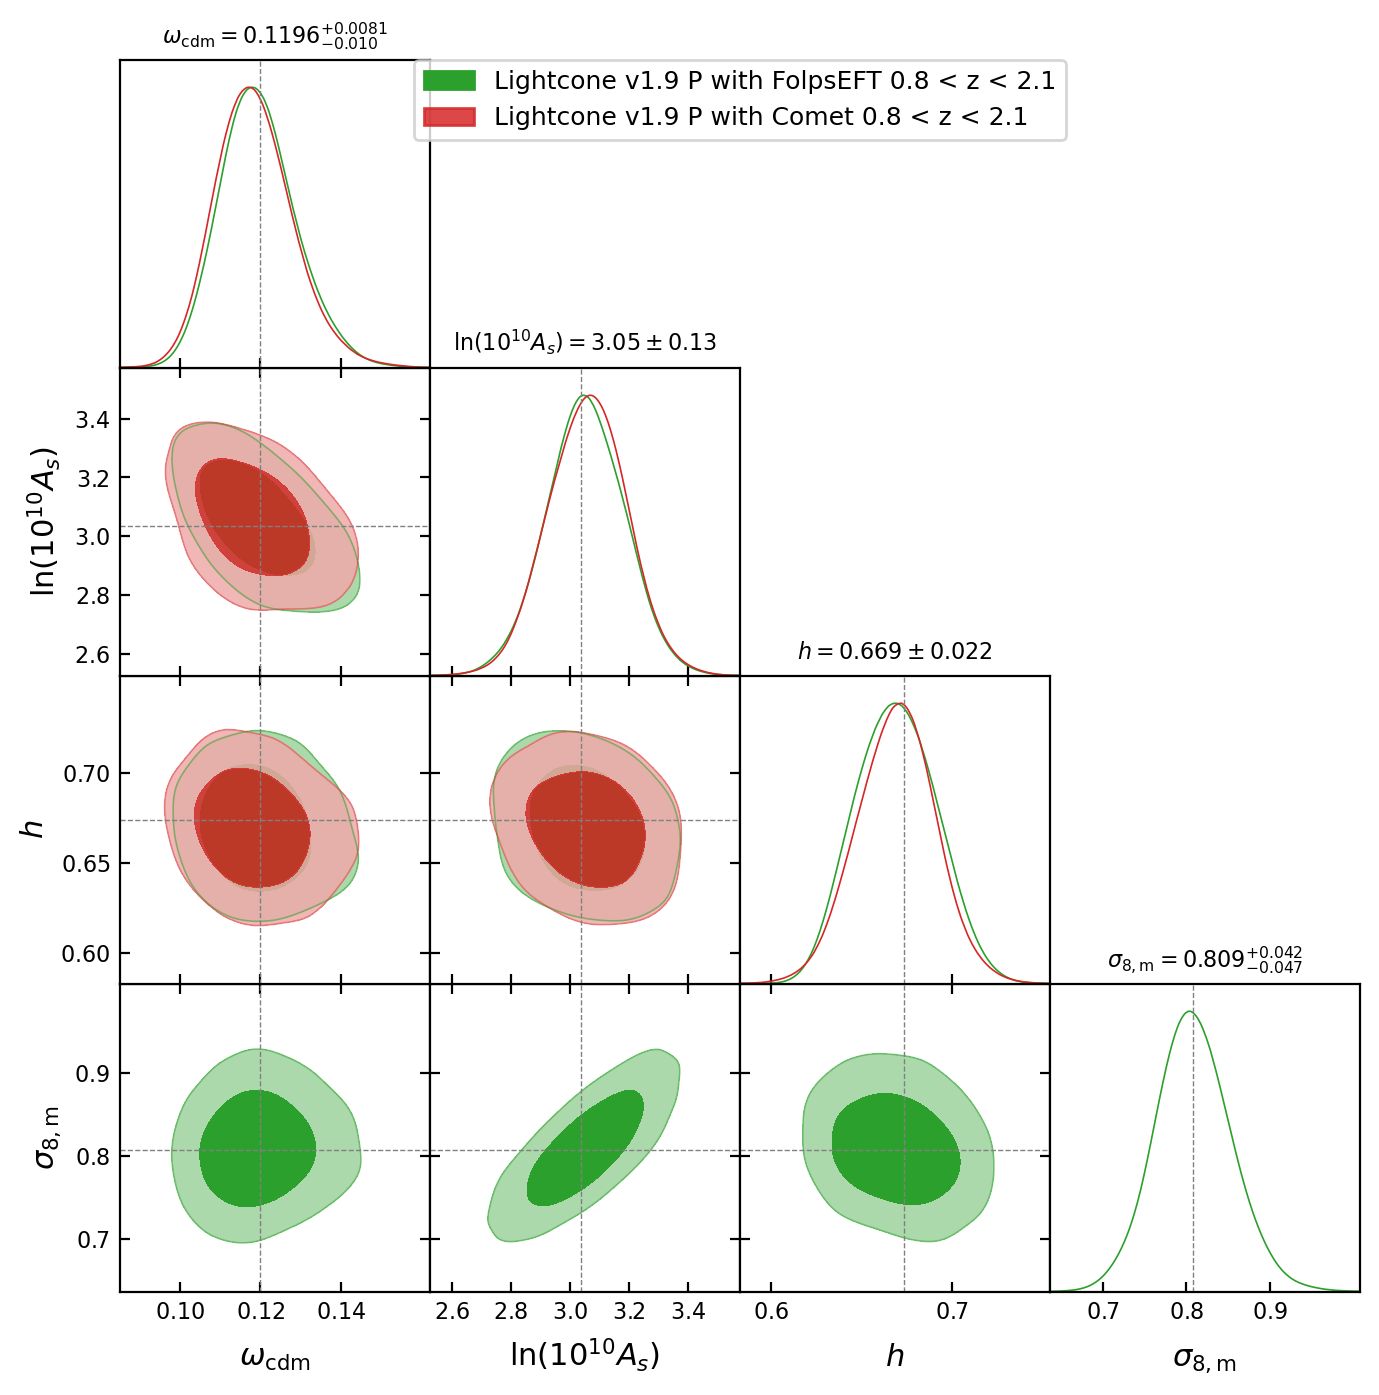

truth      mean  \
label                                        parameter                       
Lightcone v1.9 P with FolpsEFT 0.8 < z < 2.1 omega_cdm  0.120000  0.119562   
                                             logA       3.036394  3.052890   
                                             h          0.673600  0.669251   
                                             sigma8_m   0.807635  0.808788   
Lightcone v1.9 P with Comet 0.8 < z < 2.1    omega_cdm  0.120000  0.118568   
                                             logA       3.036394  3.059115   
                                             h          0.673600  0.669166   
                                             sigma8_m   0.807635  0.825827   

                                                               sigma  \
label                                        parameter                 
Lightcone v1.9 P with FolpsEFT 0.8 < z < 2.1 omega_cdm  9.468844e-03   
                                             logA       1.331704e-01   
                                             h          2.231578e-02   
                                             sigma8_m   4.610554e-02   
Lightcone v1.9 P with Comet 0.8 < z < 2.1    omega_cdm  9.651951e-03   
                                             logA       1.325996e-01   
                                             h          2.167921e-02   
                                             sigma8_m   2.220611e-16   

                                                           delta  \
label                                        parameter             
Lightcone v1.9 P with FolpsEFT 0.8 < z < 2.1 omega_cdm -0.000438   
                                             logA       0.016496   
                                             h         -0.004349   
                                             sigma8_m   0.001153   
Lightcone v1.9 P with Comet 0.8 < z < 2.1    omega_cdm -0.001432   
                                             logA       0.022720   
                                             h         -0.004434   
                                             sigma8_m   0.018192   

                                                                pull  \
label                                        parameter                 
Lightcone v1.9 P with FolpsEFT 0.8 < z < 2.1 omega_cdm -4.625119e-02   
                                             logA       1.238696e-01   
                                             h         -1.948858e-01   
                                             sigma8_m   2.500963e-02   
Lightcone v1.9 P with Comet 0.8 < z < 2.1    omega_cdm -1.483886e-01   
                                             logA       1.713461e-01   
                                             h         -2.045181e-01   
                                             sigma8_m   8.192334e+13   

                                                            abs_pull  
label                                        parameter                
Lightcone v1.9 P with FolpsEFT 0.8 < z < 2.1 omega_cdm  4.625119e-02  
                                             logA       1.238696e-01  
                                             h          1.948858e-01  
                                             sigma8_m   2.500963e-02  
Lightcone v1.9 P with Comet 0.8 < z < 2.1    omega_cdm  1.483886e-01  
                                             logA       1.713461e-01  
                                             h          2.045181e-01  
                                             sigma8_m   8.192334e+13

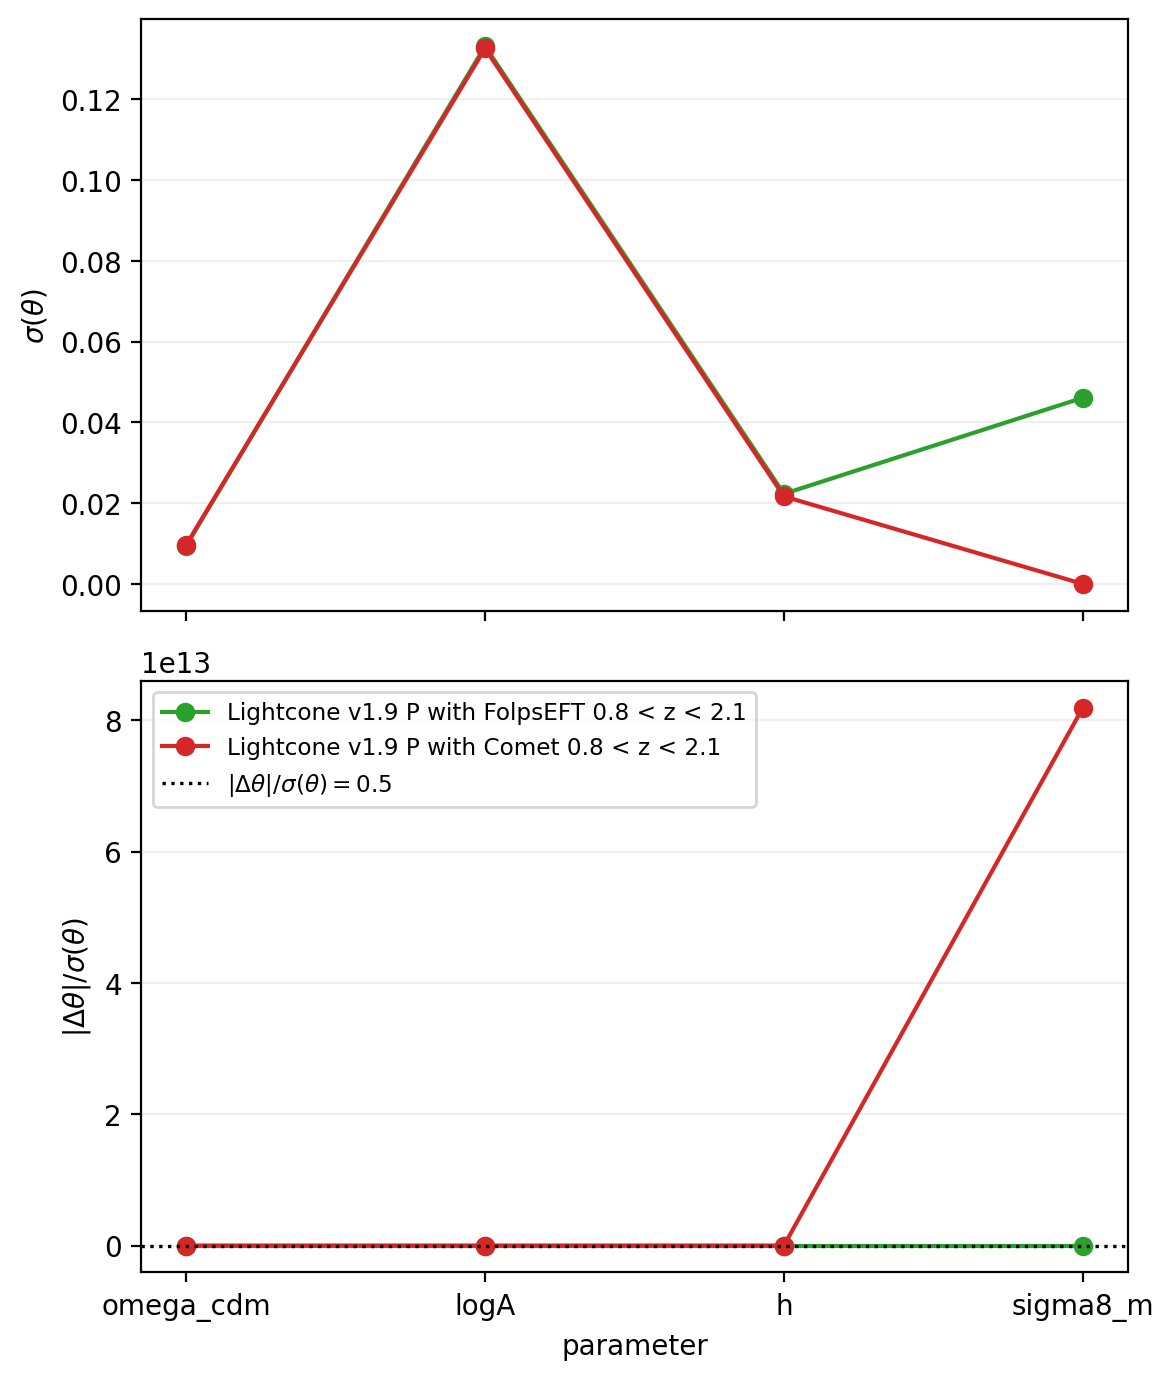

In [30]:
from desilike.samples import MCSamples, plotting
from pathlib import Path
from cosmoprimo.fiducial import AbacusSummit
from full_shape import tools
from IPython.display import display
import pandas as pd
import sys
import re
import warnings
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

# params_toplot = ['omega_cdm', 'logA', 'h', 'QSO-z1.475.X_FoG']
# params_toplot = ['omega_cdm', 'logA', 'h']
params_toplot = ['omega_cdm', 'logA', 'h', 'sigma8_m']

cosmo = AbacusSummit()
# truth = {p: cosmo[p] for p in params_toplot if p in cosmo}
truth = {
    p: cosmo.sigma8_m if p == 'sigma8_m' else cosmo.get(p)
    for p in params_toplot
}

CHAIN_CONFIGS = [
    {
        'label': 'Lightcone v1.9 P with FolpsEFT 0.8 < z < 2.1',
        'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/abacus-hf-lc-dr2-v1.9/cosmo-base_QSO1-S2-7b3c7d8a'),
        'enabled': True,
        'nchains': 4,
        'burnin': 0.3,
        'thin': 10,
        'color': 'C2',
    },
    {
        'label': 'Lightcone v1.9 P with Comet 0.8 < z < 2.1',
        'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/abacus-hf-lc-dr2-v1.9/cosmo-base_QSO1-S2-c80b3032'),
        'enabled': True,
        'nchains': 4,
        'burnin': 0.3,
        'thin': 10,
        'color': 'C3',
    },
    # {
    #     'label': 'Lightcone v1.9 P with FolpsD 0.8 < z 2.1',
    #     'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/abacus-hf-lc-dr2-v1.9/cosmo-base_QSO1-S2-cb458d57'),
    #     'enabled': True,
    #     'nchains': 4,
    #     'burnin': 0.3,
    #     'thin': 10,
    #     'color': 'C1',
    # },
    # {
    #     'label': 'Lightcone v1.9 P+B with FolpsD 0.8 < z < 2.1',
    #     'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/abacus-hf-lc-dr2-v1.9/cosmo-base_QSO1-S2+QSO1-S3-95fa0392'),
    #     'enabled': True,
    #     'nchains': 4,
    #     'burnin': 0.3,
    #     'thin': 10,
    #     'color': 'C6',
    # },
    # {
    #     'label': 'P FolpsD (dk = 0.005)',
    #     # 'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG1-S2+LRG1-S3-bc7461ef'),
    #     'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/jul17_dk005/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG2-S2-826b405a'),
    #     'enabled': True,
    #     'nchains': 4,
    #     'burnin': 0.3,
    #     'thin': 10,
    #     'color': 'C1',
    # },
    # {
    #     'label': 'P FolpsD (dk = 0.01)',
    #     # 'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG1-S2+LRG1-S3-bc7461ef'),
    #     'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/jul17_dk01/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG2-S2-132dfc43'),
    #     'enabled': True,
    #     'nchains': 4,
    #     'burnin': 0.3,
    #     'thin': 10,
    #     'color': 'C2',
    # },
    # {
    #     'label': 'P+B FolpsD (dk = 0.01 with 0.005 bk theory)',
    #     # 'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG1-S2+LRG1-S3-bc7461ef'),
    #     'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/jul18/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG2-S2+LRG2-S3-63740048'),
    #     'enabled': True,
    #     'nchains': 4,
    #     'burnin': 0.3,
    #     'thin': 10,
    #     'color': 'C1',
    # },
    # {
    #     'label': 'P+B FolpsD (dk = 0.01)',
    #     # 'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG1-S2+LRG1-S3-cfa9065b'),
    #     # 'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG2-S2+LRG2-S3-d5440e6d'),
    #     'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/jul17/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG2-S2+LRG2-S3-05e9bf55'),
    #     'enabled': True,
    #     'nchains': 4,
    #     'burnin': 0.3,
    #     'thin': 5,
    #     'color': 'C2',
    # },
    # {
    #     'label': 'P+B FolpsD (Prakhar)',
    #     # 'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG1-S2+LRG1-S3-cfa9065b'),
    #     # 'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG2-S2+LRG2-S3-d5440e6d'),
    #     'base_dir': Path('/pscratch/sd/p/prakharb/desi-clustering-live-work/fits/lrg2_folpsD_lcdm_p035_p025_b020_b003_vdg_treeloop_newenv/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG2-S2+LRG2-S3-2a1f4ee2'),
    #     'enabled': True,
    #     'nchains': 4,
    #     'burnin': 0.3,
    #     'thin': 5,
    #     'color': 'C2',
    # },
    # {
    #     'label': 'P+B FolpsD (dk = 0.005)',
    #     # 'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/folpsd-update/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG2-S2+LRG2-S3-d5440e6d'),
    #     'base_dir': Path('/pscratch/sd/e/epaillas/fits_abacus_mocks/jul17_dk005/abacus-hf-dr2-v2-altmtl/cosmo-base_LRG2-S2+LRG2-S3-11dcbf5a'),
    #     'enabled': True,
    #     'nchains': 4,
    #     'burnin': 0.3,
    #     'thin': 10,
    #     'color': 'C3',
    # },
]


def get_chain_filenames(base_dir, nchains=None):
    base_dir = Path(base_dir)
    if nchains is None:
        chain_fns = sorted(base_dir.glob('samples_*.h5'))
    else:
        chain_fns = [base_dir / f'samples_{i}.h5' for i in range(1, nchains + 1)]
    if not chain_fns:
        raise FileNotFoundError(f'No samples_*.h5 files found in {base_dir}')
    return chain_fns


def load_fit_metadata(base_dir):
    base_dir = Path(base_dir)
    match = re.search(r'-([0-9a-f]{8})(?:_|$)', base_dir.name)
    filename_hash = match.group(1) if match else None
    config_path = base_dir / 'config.yaml'
    metadata = {
        'base_dir': base_dir,
        'filename_hash': filename_hash,
        'config_path': config_path if config_path.is_file() else None,
        'hash_matches': None,
        'options': None,
        'scale_cuts': None,
    }
    if not config_path.is_file():
        warnings.warn(
            f'No config.yaml found for fit {base_dir.name}; scale cuts are unknown.',
            stacklevel=2,
        )
        return metadata

    options = tools.read_options(config_path)
    hash_options = {key: options[key] for key in ('likelihoods', 'cosmology')}
    config_hash = tools._hash_options(hash_options)
    metadata['options'] = options
    if filename_hash is not None:
        metadata['hash_matches'] = config_hash == filename_hash
        if not metadata['hash_matches']:
            warnings.warn(
                f'Config hash {config_hash} does not match filename hash {filename_hash} '
                f'for {base_dir.name}.',
                stacklevel=2,
            )

    scale_cuts = []
    for ilikelihood, likelihood in enumerate(options.get('likelihoods', [])):
        for iobservable, observable in enumerate(likelihood.get('observables', [])):
            stat = observable.get('stat', {})
            tracer = observable.get('catalog', {}).get('tracer')
            for selection in stat.get('select', []):
                scale_cuts.append({
                    'likelihood': ilikelihood,
                    'observable': iobservable,
                    'tracer': tracer,
                    'stat': stat.get('kind'),
                    'ells': selection.get('ells'),
                    'k': selection.get('k'),
                })
    metadata['scale_cuts'] = scale_cuts
    return metadata


def fit_metadata_tables(fit_metadata, labels=None):
    if labels is None:
        labels = [metadata['base_dir'].name for metadata in fit_metadata]
    if len(labels) != len(fit_metadata):
        raise ValueError('labels and fit_metadata must have the same length')

    def config_status(metadata):
        if metadata['config_path'] is None:
            return 'config missing'
        if metadata['hash_matches'] is True:
            return 'match'
        if metadata['hash_matches'] is False:
            return 'mismatch'
        return 'unverified'

    fit_columns = [
        'label', 'hash', 'config_status', 'cosmology_model', 'template', 'engine',
        'sampler', 'nchains', 'resume', 'rng', 'nparallel', 'batch_size',
        'min_steps', 'gelman_rubin', 'ess', 'thinning', 'profiler', 'profile_iterations',
    ]
    observable_columns = [
        'label', 'hash', 'tracer', 'zsnap', 'data_version',
        'catalog_cosmo', 'stat', 'ells',
        'kmin', 'kmax', 'kstep', 'theory_model', 'prior_basis', 'damping',
        'damping_method',
    ]
    fit_rows, observable_rows = [], []
    for label, metadata in zip(labels, fit_metadata):
        status = config_status(metadata)
        options = metadata['options']
        if options is None:
            fit_rows.append({'label': label, 'hash': metadata['filename_hash'], 'config_status': status})
            observable_rows.append({'label': label, 'hash': metadata['filename_hash'], 'config_status': status})
            continue

        cosmology = options.get('cosmology', {})
        sampler = options.get('sampler', {})
        sampler_init = sampler.get('init', {})
        sampler_run = sampler.get('run', {})
        profiler = options.get('profiler', {})
        profiler_run = profiler.get('maximize', {})
        fit_rows.append({
            'label': label, 'hash': metadata['filename_hash'], 'config_status': status,
            'cosmology_model': cosmology.get('model'), 'template': cosmology.get('template'),
            'engine': cosmology.get('engine'), 'sampler': sampler.get('sampler'),
            'nchains': sampler.get('nchains'), 'resume': sampler.get('resume'),
            'rng': sampler_init.get('rng'), 'nparallel': sampler_init.get('nparallel'),
            'batch_size': sampler_init.get('batch_size'), 'min_steps': sampler_run.get('min_steps'),
            'gelman_rubin': sampler_run.get('gelman_rubin'), 'ess': sampler_run.get('ess'),
            'thinning': sampler_run.get('thinning'), 'profiler': profiler.get('profiler'),
            'profile_iterations': profiler_run.get('niterations'),
        })

        for likelihood in options.get('likelihoods', []):
            for observable in likelihood.get('observables', []):
                catalog = observable.get('catalog', {})
                stat = observable.get('stat', {})
                theory = observable.get('theory', {})
                selections = stat.get('select', []) or [{}]
                for selection in selections:
                    k = selection.get('k') or []
                    ells = selection.get('ells')
                    observable_rows.append({
                        'label': label, 'hash': metadata['filename_hash'], 'config_status': status,
                        'tracer': catalog.get('tracer'), 'zsnap': catalog.get('zsnap'),
                        'data_version': catalog.get('version'), 'catalog_cosmo': catalog.get('cosmo'),
                        'hod': catalog.get('hod'), 'los': catalog.get('los'), 'imock': catalog.get('imock'),
                        'stat': stat.get('kind'), 'basis': stat.get('basis'),
                        'ells': tuple(ells) if isinstance(ells, list) else ells,
                        'kmin': k[0] if len(k) > 0 else None, 'kmax': k[1] if len(k) > 1 else None,
                        'kstep': k[2] if len(k) > 2 else None, 'theory_model': theory.get('model'),
                        'prior_basis': theory.get('prior_basis'), 'damping': theory.get('damping'),
                        'damping_method': theory.get('damping_method'), 'marg': theory.get('marg'),
                        'coevolution': theory.get('coevolution'), 'A_full': theory.get('A_full'),
                    })

    return (
        pd.DataFrame(fit_rows, columns=fit_columns),
        pd.DataFrame(observable_rows, columns=observable_columns),
    )


def display_fit_metadata(fit_metadata, labels=None):
    fit_table, observable_table = fit_metadata_tables(fit_metadata, labels=labels)
    display(fit_table)
    display(observable_table)
    return fit_table, observable_table


def fix_latex_namespace_subscripts(chain):
    r"""Avoid mathtext double-subscript errors for labels like b_\mathrm{td}."""
    for param in chain._data:
        latex = getattr(param, '_latex', None)
        if latex is None:
            continue
        param._latex = re.sub(r'_(\\mathrm\{[^{}]+\})', r'_{\1}', latex)
    return chain


def load_chain(config):
    burnin = config.get('burnin', 0.3)
    thin = config.get('thin', 10)
    chain_fns = get_chain_filenames(config['base_dir'], nchains=config.get('nchains'))
    chain = MCSamples.concatenate([
        MCSamples.read(fn).remove_burnin(burnin if burnin is not None else 0.)
        for fn in chain_fns
    ])
    if thin:
        chain = chain[::thin]
    chain = fix_latex_namespace_subscripts(chain)
    return chain


def load_chain_comparison(configs):
    enabled_configs = [config for config in configs if config.get('enabled', True)]
    if not enabled_configs:
        raise ValueError('Enable at least one chain in CHAIN_CONFIGS.')
    chains = [load_chain(config) for config in enabled_configs]
    fit_metadata = [load_fit_metadata(config['base_dir']) for config in enabled_configs]
    legends = [config['label'] for config in enabled_configs]
    colors = None
    if any('color' in config for config in enabled_configs):
        colors = [config.get('color', f'C{i}') for i, config in enumerate(enabled_configs)]
    return chains, legends, colors, fit_metadata


chains, legends, colors, fit_metadata = load_chain_comparison(CHAIN_CONFIGS)
fit_table, observable_table = display_fit_metadata(fit_metadata, legends)

plot_kwargs = dict(
    params=params_toplot,
    title_limit=1,
    markers=truth,
    legend_labels=legends,
    filled=[True, True, True],
)
if colors is not None:
    plot_kwargs['contour_colors'] = colors

plotting.plot_triangle(chains, **plot_kwargs)
plt.show()


def parameter_bias_table(chains, labels, truth, params):
    """Return posterior offsets and pulls for parameters with known truth."""
    if len(chains) != len(labels):
        raise ValueError('chains and labels must have the same length')
    bias_params = [param for param in params if param in truth]
    skipped = [param for param in params if param not in truth]
    if skipped:
        warnings.warn(f'Skipping parameters without truth values: {skipped}', stacklevel=2)
    if not bias_params:
        raise ValueError('None of the requested parameters has a truth value')

    rows = []
    for label, chain in zip(labels, chains):
        for param in bias_params:
            mean = float(chain.mean(params=param))
            sigma = float(chain.std(params=param))
            if not sigma > 0.:
                raise ValueError(f'Non-positive posterior uncertainty for {param!r} in {label!r}')
            delta = mean - float(truth[param])
            pull = delta / sigma
            rows.append({
                'label': label, 'parameter': param, 'truth': float(truth[param]),
                'mean': mean, 'sigma': sigma, 'delta': delta,
                'pull': pull, 'abs_pull': abs(pull),
            })
    return pd.DataFrame(rows).set_index(['label', 'parameter']), bias_params


bias_table, bias_params = parameter_bias_table(chains, legends, truth, params_toplot)
display(bias_table)

fig, (ax_sigma, ax_bias) = plt.subplots(
    nrows=2, sharex=True,
    figsize=(max(6, 1.5 * len(bias_params)), 7),
)
x = list(range(len(bias_params)))
for ichain, label in enumerate(legends):
    values = bias_table.xs(label, level='label').reindex(bias_params)
    kwargs = {'color': colors[ichain]} if colors is not None else {}
    ax_sigma.plot(x, values['sigma'], marker='o', label=label, **kwargs)
    ax_bias.plot(x, values['abs_pull'], marker='o', label=label, **kwargs)
ax_sigma.set_ylabel(r'$\sigma(\theta)$')
ax_sigma.grid(axis='y', alpha=0.2)
ax_bias.axhline(0.5, color='black', linestyle=':', linewidth=1.2, label=r'$|\Delta\theta|/\sigma(\theta)=0.5$')
ax_bias.set_xticks(x, bias_params)
ax_bias.set_ylabel(r'$|\Delta\theta|/ \sigma(\theta)$')
ax_bias.set_xlabel('parameter')
ax_bias.legend(fontsize='small')
ax_bias.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()

/global/cfs/cdirs/desicollab/users/akrolew/C3PO/chains/Abacus_tests/rescaled_3dcov/FS/QSO_ana_cov_AP_repar_v1.9/chain.1.txt
/global/cfs/cdirs/desicollab/users/akrolew/C3PO/chains/Abacus_tests/rescaled_3dcov/FS/QSO_ana_cov_AP_repar_v1.9/chain.10.txt
/global/cfs/cdirs/desicollab/users/akrolew/C3PO/chains/Abacus_tests/rescaled_3dcov/FS/QSO_ana_cov_AP_repar_v1.9/chain.11.txt
/global/cfs/cdirs/desicollab/users/akrolew/C3PO/chains/Abacus_tests/rescaled_3dcov/FS/QSO_ana_cov_AP_repar_v1.9/chain.12.txt
/global/cfs/cdirs/desicollab/users/akrolew/C3PO/chains/Abacus_tests/rescaled_3dcov/FS/QSO_ana_cov_AP_repar_v1.9/chain.13.txt
/global/cfs/cdirs/desicollab/users/akrolew/C3PO/chains/Abacus_tests/rescaled_3dcov/FS/QSO_ana_cov_AP_repar_v1.9/chain.14.txt
/global/cfs/cdirs/desicollab/users/akrolew/C3PO/chains/Abacus_tests/rescaled_3dcov/FS/QSO_ana_cov_AP_repar_v1.9/chain.15.txt
/global/cfs/cdirs/desicollab/users/akrolew/C3PO/chains/Abacus_tests/rescaled_3dcov/FS/QSO_ana_cov_AP_repar_v1.9/chain.16.txt
/

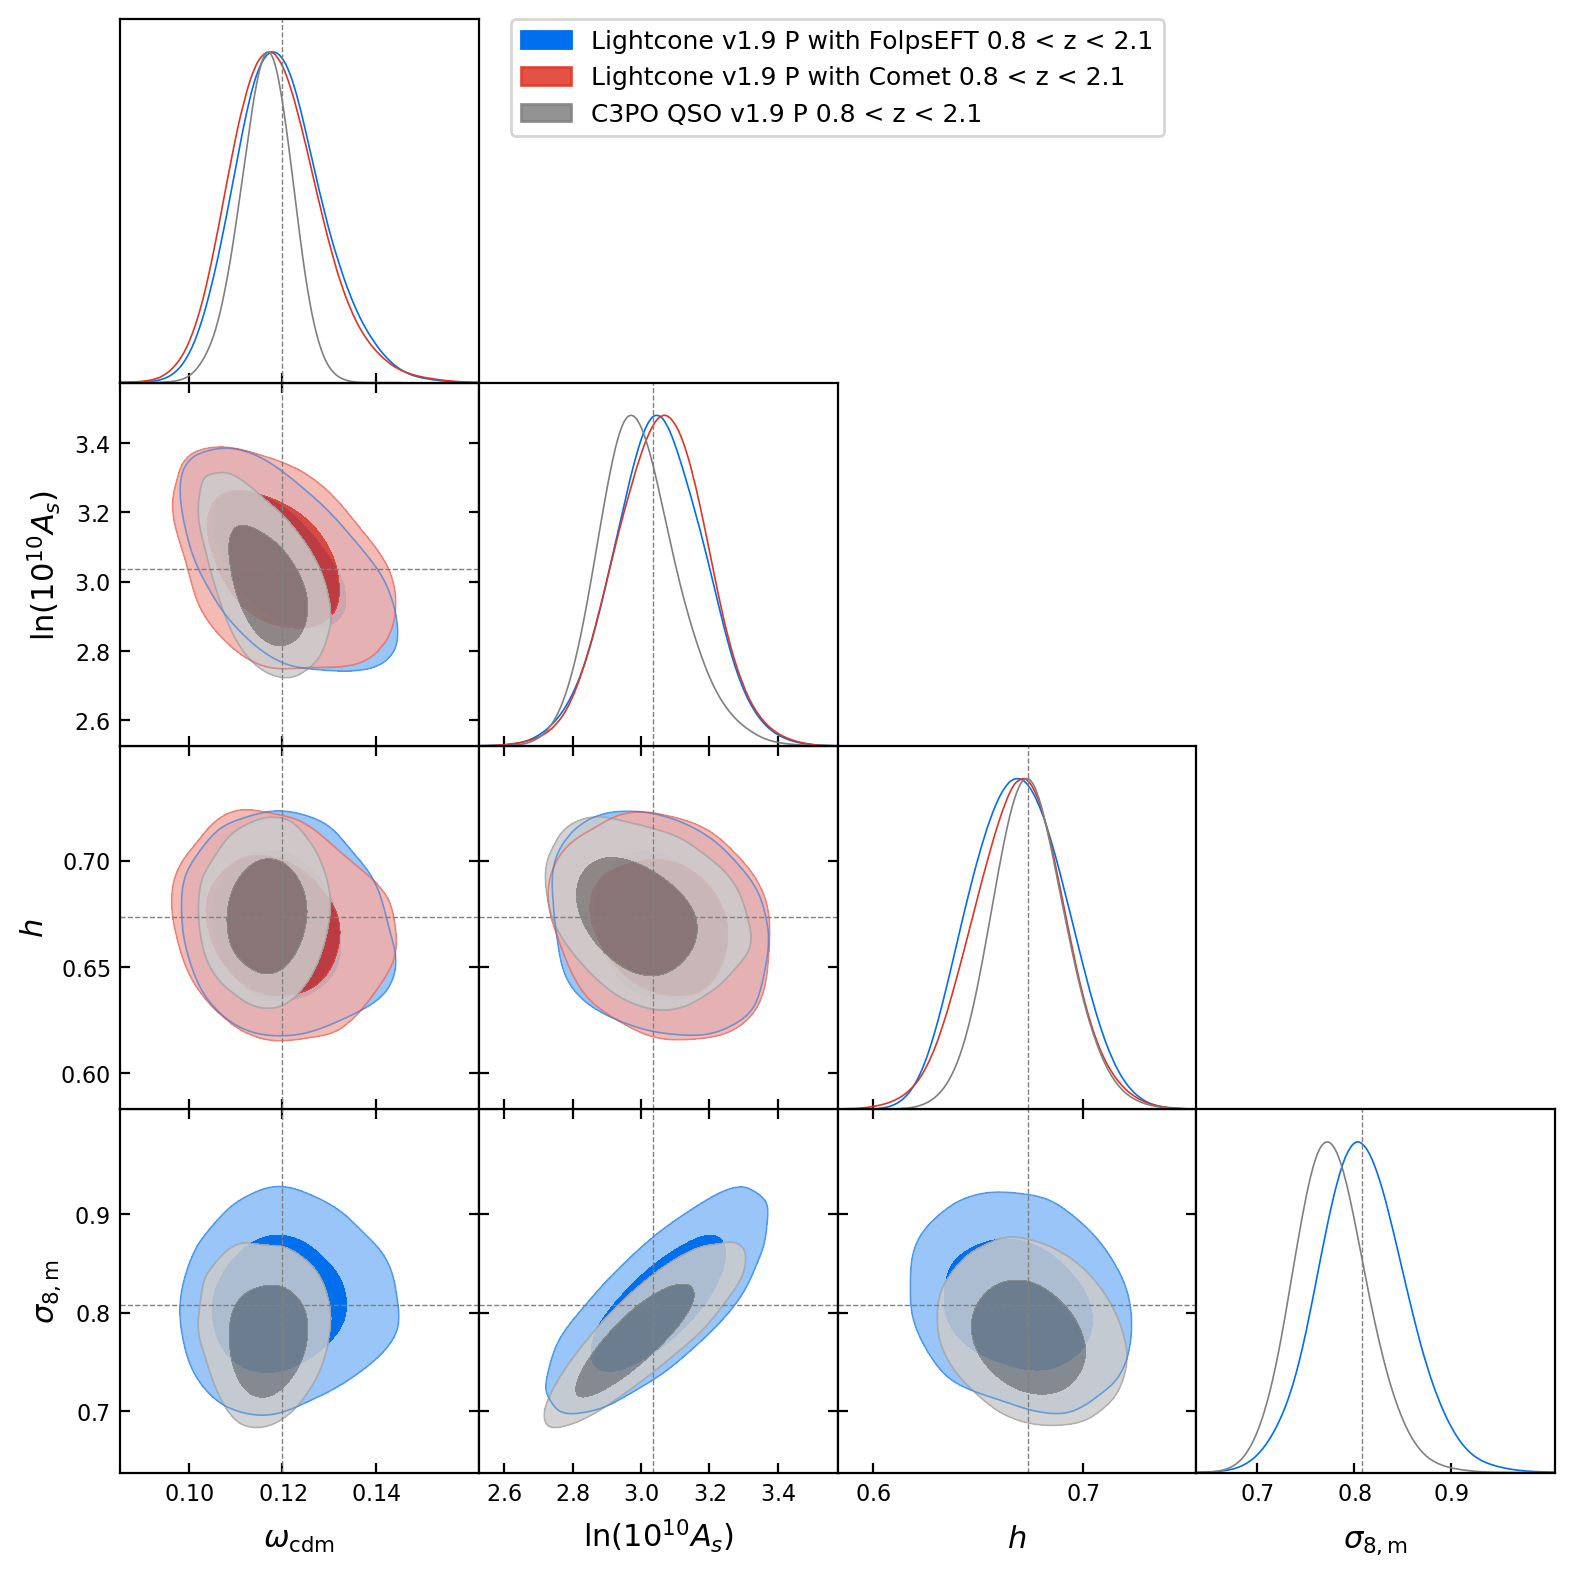

In [31]:
# Cobaya/GetDist chain adapter (kept separate from the existing workflow above).
import numpy as np
from getdist import loadMCSamples
from desilike import Variable
from desilike.samples import MCSamples


def _getdist_parameter_names(samples):
    return [parameter.name for parameter in samples.getParamNames().names]


def add_desilike_parameter_aliases(samples):
    """Add names used by this notebook to a GetDist chain in place."""
    names = set(_getdist_parameter_names(samples))
    parameters = samples.getParams()
    aliases = [
        ('h', 'H0', lambda value: value / 100.0, 'h'),
        ('n_s', 'ns', lambda value: value, r'n_s'),
        ('Omega_m', 'omegam', lambda value: value, r'\Omega_m'),
        ('sigma8_m', 'sigma8', lambda value: value, r'\sigma_8'),
    ]
    for target, source, transform, latex in aliases:
        if target not in names and source in names:
            samples.addDerived(
                transform(getattr(parameters, source)), name=target, label=latex,
            )
            names.add(target)
    return samples


def getdist_to_desilike(samples):
    """Convert GetDist samples to a weighted desilike ``MCSamples``."""
    if hasattr(MCSamples, 'from_getdist'):
        return MCSamples.from_getdist(samples)

    data = {}
    for index, parameter in enumerate(samples.getParamNames().names):
        variable = Variable(
            parameter.name,
            latex=parameter.label or parameter.name,
            derived=bool(parameter.isDerived),
        )
        data[variable] = np.asarray(samples.samples[:, index])

    chain = MCSamples(data)
    chain.aweight = np.asarray(samples.weights)
    chain.logposterior = -np.asarray(samples.loglikes)
    return chain


def load_cobaya_chain(path, burnin=0.3):
    """Load all ``chain.N.txt`` files at a directory or chain prefix."""
    path = Path(path)
    prefix = path / 'chain' if path.is_dir() else path
    chain_files = sorted(prefix.parent.glob(f'{prefix.name}.*.txt'))
    if not chain_files:
        raise FileNotFoundError(
            f'No {prefix.name}.*.txt files found in {prefix.parent}'
        )
    samples = loadMCSamples(
        str(prefix), settings={'ignore_rows': burnin}, no_cache=True,
    )
    add_desilike_parameter_aliases(samples)
    return getdist_to_desilike(samples)


C3PO_CHAIN_DIR = Path(
    '/global/cfs/cdirs/desicollab/users/akrolew/C3PO/chains/Abacus_tests/'
    'rescaled_3dcov/FS/QSO_ana_cov_AP_repar_v1.9'
)

# Example: load and append without changing the original ``chains`` list.
c3po_chain = load_cobaya_chain(C3PO_CHAIN_DIR, burnin=0.3)
plotting.plot_triangle(
    [*chains, c3po_chain], params=params_toplot,
    legend_labels=[*legends, 'C3PO QSO v1.9 P 0.8 < z < 2.1'], markers=truth,
    filled=[True, True, True],
)
